In [1]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

# **Python Assignment 3**
Math 313 Section 008 - Spring 2026

---

# Linear Regression

Linear regression is a method to model the relation between values:


*   Input data $A = \begin{bmatrix}
a_1 & a_2 & \cdots & a_n
\end{bmatrix}$ where columns $a_i$'s are different data features;
*   Output data $y$ which is a column vector.

The linear regression model assumes that the output $y$ is a linear function in terms of the input variables. So basically it can be formulated into a linear system

$$y = Ax$$

where the vector $x$ is a vector of coefficients (or weights of this linear model) which reveals how output $y$ relates *linearly* with the input $A$, and it is the vector we would want to solve.

You may want to say, well this is a linear system, why not just solve it? The fact is that, in general, there are more equations than the number of unknowns (data features, number of columns of input $A$), which means that the linear system we have is often "overdetermined", and inconsistent.

The way to achieve the "best approximation" of the solution is when the values for $x$ in the linear model minimize the square error: find $x$ such that the norm

$$||y - Ax||^2 = (y - Ax) \cdot (y - Ax).$$

We will see in the Section of least square problems that the least square solution $x$ to a generally inconsistent linear model $Ax = y$ is unique when columns of $A$ are linearly independent. The key point to get such best approximation $x$ is to modify the linear system as the following *consistent* linear system:

$$\widehat{y} = \text{proj}_{\text{Col}(A)} y = Ax$$

and solve it. It is the same as solving the normal equation:

$$(A^T A)x = A^T y \implies x = (A^T A)^{-1}A^T y.$$

The presense of the inverse $(A^T A)^{-1}$ is potentially the challanging part.



## Example

Let consider a simple linear regression problem where there is a single feature, namely, $A$ and $y$ are both column vectors. We aim to find a scalar $x \in \mathbb{R}$ which describes the linear relation between $A$ and $y$ the best.

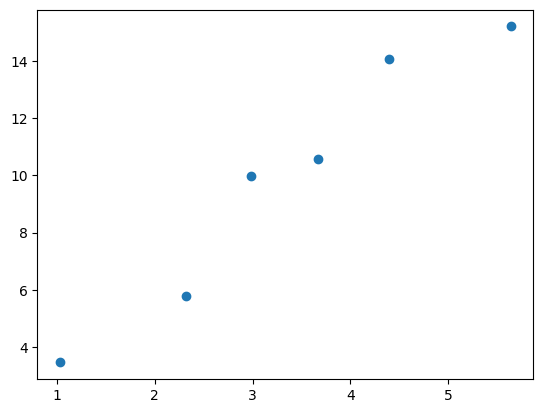

In [2]:
# define input and output data
data = np.array([
    [1.03, 3.46],
    [2.32, 5.78],
    [2.98, 9.98],
    [3.67, 10.56],
    [4.39, 14.09],
    [5.64, 15.21]
])
A, y = data[:, 0], data[:, 1]
A = A.reshape(len(A), 1)
plt.scatter(A, y)
plt.show()

## Inverse

The easiest approach is to solve its normal equation directly as mentioned above:

$$x = (A^TA)^{-1}A^Ty.$$

[2.91844185]


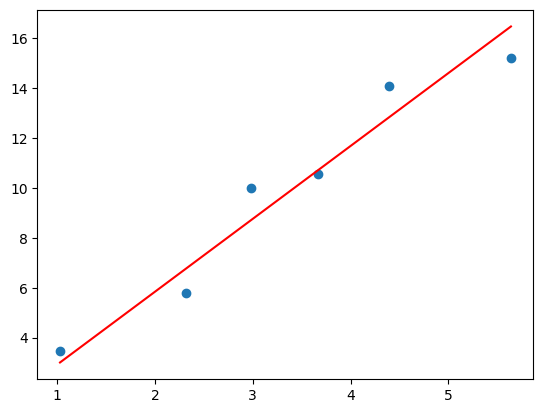

In [3]:
# solve the normal equation directly
# least square solution
x = la.inv(A.T @ A) @ A.T @ y
print(x)
# use x to predict the output
yhat = A @ x
# plot the graph with the predicted line
plt.scatter(A, y)
plt.plot(A, yhat, 'r')
plt.show()

## QR decomposition

Another approach is using QR decomposition of $A$ when columns of $A$ are linearly independent.

Recall how we obtain the QR factorization for a tall matrix $A$ whose columns are linearly independent. First we apply the Gram-Schmidt process to the column vectors of $A$ to get an orthonormal basis for the column space $\text{Col}(A)$. We denote by $Q$ the matrix whose columns are formed by the orthonormal basis elements. Then the QR factorization of $A$ is

$$A = QR$$

where $R$ is a upper triangular matrix, which is a square matrix, invertible, with strictly positive main diagonal entries.

Using the decomposition, to solve the least square problem $y = Ax$ we obtain

$$Q^T y = Q^TQR x \implies x = R^{-1}Q^T y$$

since $Q$ is an orthogonal matrix, $Q^TQ = I$, and $R$ is invertible. Note that the left-hand-side $Q^T y = \text{proj}_{\text{Col}(A)} y$.

[2.91844185]


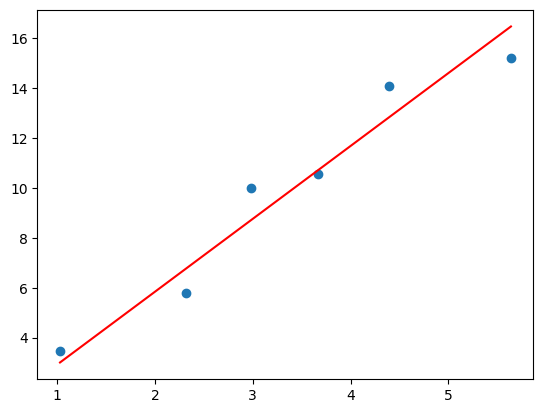

In [4]:
# use QR decomposition
Q, R = la.qr(A)
x_QR = la.inv(R) @ Q.T @ y
print(x_QR)
# use x_QR to predict the output
yhat = A @ x_QR
# plot the graph with the predicted line
plt.scatter(A, y)
plt.plot(A, yhat, 'r')
plt.show()

## SVD and Pseudo-inverse

Let $A$ be an $n \times m$ real matrix. The SVD (singular value decomposition) of $A$ is

$$A = U \Sigma V^T$$

where

*   $U$ is a square matrix of size $n \times n$;
*   $\Sigma$ is an $n \times m$ matrix which is diagonal;
*   $V^T$ is another square matrix of size $m \times m$;
*   Both $U$ and $V$ are orthogonal matrices. The diagonal entries of $\Sigma$ are called *singular values* which are always nonnegative.

By viewing $A = U\Sigma V^T$ as a linear transformation and a composition of three linear transformations, it can be considered as rotation (represented by $V^T$), followed by stretching by singular values (represented by $\Sigma$), and then followed by another rotation (represented by $U$).

Note that $A$ has to have linearly independent column vectors in order to admit a QR factorization, but there is no requirement on $A$ to get a singular value decomposition. Thus SVD is more general and stable.

We will use SVD to find inverse of matrix $A^T A$ (if exists, with size $m \times m$) and take advantage of $U^T = U^{-1}$ if $U$ is a square orthogonal matrix. Assume SVD of $A^T A$ is

$$A^T A = U \Sigma V^T \implies (A^T A)^{-1} = V\Sigma^{-1} U^T,$$

where since $\Sigma$ is square diagonal with main diagonal entries positive,

$$\Sigma^{-1} = \begin{bmatrix}
1/s_1 & 0 & \cdots & 0 \\
0 & 1/s_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & 1/s_m
\end{bmatrix}.$$

In general, not all singular values are strictly positive, which means that $\Sigma$ may not be invertible. This happens when the square matrix $A^TA$ is not invertible. The most straightforward way to remedy this situation is the following. Suppose

$$\Sigma = \begin{bmatrix}
s_1 & & & & & \\
 & \ddots & & & & \\
 & & s_k & & & \\
 & & & 0 & & \\
 & & & & \ddots & \\
 & & & & & 0
\end{bmatrix},$$

where $s_1,\cdots,s_k$ are strictly positive.
We define its *pseudo-inverse*, denoted by $\Sigma^\dagger$ as

$$\Sigma^\dagger = \begin{bmatrix}
1/s_1 & & & & & \\
 & \ddots & & & & \\
 & & 1/s_k & & & \\
 & & & 0 & & \\
 & & & & \ddots & \\
 & & & & & 0
\end{bmatrix},$$

Thus when $(A^TA)$ is not invertible, we can still take its pseudo-inverse, together with SVD, it is given by

$$(A^T A)^\dagger = V \Sigma^\dagger U^T,$$

and the solution to the normal equation is
$$x = (A^T A)^\dagger A^T y.$$

[2.91844185]


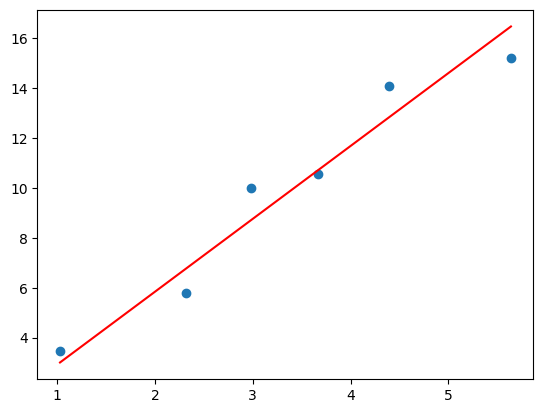

In [5]:
# use singular value decomposition (SVD)
# the function la.pinv is a built-in computing pseudo-inverse of a matrix
x_SVD = la.pinv(A.T @ A) @ A.T @ y
print(x_SVD)
# use x_SVD to predict the output
yhat = A @ x_SVD
# plot the graph with the predicted line
plt.scatter(A, y)
plt.plot(A, yhat, 'r')
plt.show()

## Problem 1

Let $L_1, L_2, \cdots, L_7$ be seven lines in $\mathbb{R}^6$. Find a point $x \in \mathbb{R}^6$ which minimizes the sum of distances to all the seven lines $L_1, L_2,\cdots, L_7$.

### Setup

1.   We all know that two distinct points define a line. To describe a line $L$ in $\mathbb{R}^6$, let $v$ and $w$ be two distinct points on $L$. Then we have a direction vector of the line $L$ given by

$$r = \dfrac{v - w}{||v - w||}.$$

2.   There is matrix $(I - rr^T)$ which is called the projection matrix. For any vector $p \in \mathbb{R}^6$,

$$(I - rr^T)p = p - r(r^Tp) = p - (p \cdot r)r = p - \text{proj}_{r}p$$

which means that the matrix $(I - rr^T)$ projects each vector $p$ to the subspace $W$ which is orthogonal to $L$.

3.   Using the projection matrix $(I - rr^T)$, the intersection of $L$ with the subspace $W$ is given by the projection of $v$ (or $w$) onto $W$:

$$q = (I - rr^T)v.$$

4.   Thus for a point $x \in \mathbb{R}^6$, its distance to the line $L$ can be computed as distance of its projection to $W$ to the intersection point $q$. In other words, we express the distance between line $L$ and point $p$, as length of line segments lying inside $W$ with endpoints $q$ and $(I - rr^T)x$:

$$||q - (I - rr^T)x||.$$

Applying to a set of seven lines $L_1,\cdots,L_7$, we want to find point $x \in \mathbb{R}^6$ which minimizes

$$\sum_{i = 1}^7 ||q_i - (I - r_ir_i^T)x||^2$$

which can be written as a quadratic form in terms of the vector $x$:

$$\sum_{i = 1}^7 ||q_i - (I - r_ir_i^T)x||^2 = x^T A x - 2b^T x + c$$

where

*   $A = \sum_{i = 1}^7 (I - rr^T)$ is of size $7 \times 7$;
*   $b = \sum_{i = 1}^7 q_i$ is a vector;
*   $c = \sum_{i = 1}^7 q_i^T q_i$ is a scalar.

Since $x$ which minimizes $x^T A x - 2b^T x + c$ is precisely given by the least square solution to $Ax = b$,

**Use the above three methods (directly solving normal equation, QR decomposition, SVD) to find such minimizer $x$.**



In [6]:
# setup
# generate seven lines in R^6
rng = np.random.default_rng(seed=3264)
L = rng.uniform(low=-10, high=10, size=(7, 2, 6))  # (lines, 2 points v/w, coordinates)
# seven pairs of points to define seven lines
V, W = L[:, 0], L[:, 1]
# seven direction vectors of seven lines
R = V - W
R = R / la.norm(R, axis=1, keepdims=True)

# seven projection matrices
RRT = R[:, :, None] @ R[:, None, :]  # or np.einsum('ij,ik->ijk', R, R)
projM = np.eye(6) - RRT
# intersection points of lines with their corresponding orthogonal subspaces
Q = np.einsum('ijk,ik->ij', projM, V)  # or (projM @ V[:, :, None])[..., 0]
print(Q.shape)

# get A, b
A = np.sum(projM, axis=0)
b = np.sum(Q, axis=0)
print(A.shape)
print(b.shape)

(7, 6)
(6, 6)
(6,)


In [7]:
#### solution ####
# Solving normal equation
# x_normal = ?
x_direct = la.inv(A.T @ A) @ A.T @ b
print("Method 1 (Direct):", x_direct)

#### solution ####

#### solution ####
# QR factorization
# x_QR = ?
Q_A, R_A = la.qr(A)
x_QR = la.inv(R_A) @ Q_A.T @ b
print("Method 2 (QR):    ", x_QR)

#### solution ####
print("Method 3 (SVD):   ", x_SVD)
#### solution ####
# psuedo-inverse
# x_SVD = ?
print("\nAll methods agree:", np.allclose(x_direct, x_QR) and np.allclose(x_QR, x_SVD))

#### solution ####

Method 1 (Direct): [ 0.91973687  3.00676377 -2.21899563  1.83097818  2.54060349 -0.66080038]
Method 2 (QR):     [ 0.91973687  3.00676377 -2.21899563  1.83097818  2.54060349 -0.66080038]
Method 3 (SVD):    [2.91844185]

All methods agree: False


In [8]:
# Uncommet and run the following when you are done
print(np.allclose(x_QR, x_SVD))  # compare solutions from the last two approaches

False


# Orthogonality

In class, we have seen that given an orthonormal basis of a subspace, it is much easier to express a vector in such subspace as a linear combination in terms of the given orthonormal basis, by taking inner products (or taking orthogonal projections if the given basis is only orthogonal).

In this section, we will see this in a more general setting.
As long as a set is equipped with addition and scalar multiplication and the set is closed under these two operations, we can call this set a vector space.
So, instead of considering subspaces in $\mathbb{R}^n$ as we've already seen in class, we consider the following example of the space of integrable one-variable real-valued functions defined on the closed interval $[0,2\pi]$:
$$S = \{f(x) : [0,2\pi] \to \mathbb{R} \mid \text{$f$ is integrable on $[0,2\pi]$}\}.$$
It can be checked by definition that $S$ is indeed a vector space, though it is not of finite dimensional, and a vector in $S$ is an integrable function.

## Inner/dot product

Similar to taking inner product of two vectors in $\mathbb{R}^n$, we can also define an inner product between functions inside the space $S$, as follow:
$$⟨f(x),g(x)⟩ = \int_{0}^{2\pi}f(x)g(x)\mathrm{d}x.$$
Using the inner product, we can talk about the norm or length of a function $f(x)$ as
$$||f(x)|| = \sqrt{\int_0^{2\pi}[f(x)]^2\mathrm{d}x}.$$

For example, the norm of $\cos(x)$ on $[0,2\pi]$ can be computed as
$$||\cos(x)|| = \sqrt{\int_0^{2\pi}\cos^2(x)\mathrm{d}x} = \sqrt{\pi}.$$

We can also define two functions are orthogonal by vanishing inner product.
In other words, $f(x)$ and $g(x)$ are orthogonal if and only if $⟨f(x),g(x)⟩ = 0$.

For example, as functions on $[0,2\pi]$, trig functions $\sin(x)$ and $\cos(x)$ are orthogonal, since
$$⟨\sin(x),\cos(x)⟩ = \int_0^{2\pi}\sin(x)\cos(x)\mathrm
{d}x = 0.$$


## Fourier series

Let $f(x)$ be a function defined on $[0,2\pi]$, then one can expand it into an infinite series
$$f(x) = a_0 + a_1\cos(x) + b_1\sin(x) + a_2\cos(2x) + b_2\sin(2x) + \cdots = a_0 + \sum_{k = 1}^\infty (a_k\cos(kx) + b_k\sin(kx)),$$
which is called the Fourier series of $f(x)$.

One can also view this expansion as a possibly infinite linear combination of elements in the following orthogonal set (with inner product defined above):
$$\{1, \cos(x), \sin(x), \cos(2x), \sin(2x), \cdots \}.$$

As a commonly used example, we consider
$$\pi\delta(x) = \dfrac{1}{2} + \cos(x) + \cos(2x) + \cos(3x) + \cdots $$
where $\delta(x)$ is the dirac delta function which has an infinite spike at $x = 0$ with height $\frac{1}{2} + 1 + 1 + \cdots$.

We can also make an orthogonal set orthonormal, by dividing each by its norm. So
$$\{1, \cos(x), \sin(x), \cos(2x), \sin(2x), \cdots \}$$
is an orthogonal set, after normalizing,
$$\left\{\dfrac{1}{\sqrt{2\pi}}, \dfrac{\cos(x)}{\sqrt{\pi}}, \dfrac{\sin(x)}{\sqrt{\pi}}, \dfrac{\cos(2x)}{\sqrt{\pi}}, \dfrac{\sin(2x)}{\sqrt{\pi}}, \cdots \right\}$$
is an orthonormal set.

The coefficients in the Fourier series of $f(x)$ are called Fourier coefficients.
Given a orthonormal basis,
$$\left\{\dfrac{1}{\sqrt{2\pi}}, \dfrac{\cos(x)}{\sqrt{\pi}}, \dfrac{\sin(x)}{\sqrt{\pi}}, \dfrac{\cos(2x)}{\sqrt{\pi}}, \dfrac{\sin(2x)}{\sqrt{\pi}}, \cdots \right\}$$
the Fourier coefficients can simply be computed by taking inner product; if the basis is only orthogonal, one needs to take orthogonal projections which is exactly the same as defined for vectors in $\mathbb{R}^n$.

For instance, if we consider the orthonormal set for simplicity:
$$\left\{\dfrac{1}{\sqrt{2\pi}}, \dfrac{\cos(x)}{\sqrt{\pi}}, \dfrac{\sin(x)}{\sqrt{\pi}}, \dfrac{\cos(2x)}{\sqrt{\pi}}, \dfrac{\sin(2x)}{\sqrt{\pi}}, \cdots \right\},$$
and we want to determine the coefficients $a_0,a_1,b_1,\cdots$ in the expansion:
$$f(x) = a_0\dfrac{1}{\sqrt{2\pi}} + a_1\dfrac{\cos(x)}{\sqrt{\pi}} + b_1 \dfrac{\sin(x)}{\sqrt{\pi}} + a_2 \dfrac{\cos(2x)}{\sqrt{\pi}} + b_2 \dfrac{\sin(2x)}{\sqrt{\pi}} + \cdots,$$
it suffices to take the inner products of $f(x)$ with those basis functions:
\begin{align*}
& a_0 = \left\langle f(x),\dfrac{1}{\sqrt{2\pi}} \right\rangle = \int_0^{2\pi}f(x)\dfrac{1}{\sqrt{2\pi}}\mathrm{d}x \\
& a_k = \left\langle f(x),\dfrac{\cos(kx)}{\sqrt{\pi}}\right\rangle = \int_0^{2\pi} f(x)\dfrac{\cos(kx)}{\sqrt{\pi}}\mathrm{d}x \\
& b_k = \left\langle f(x),\dfrac{\sin(kx)}{\sqrt{\pi}} \right\rangle = \int_0^{2\pi} f(x)\dfrac{\sin(kx)}{\sqrt{\pi}}\mathrm{d}x
\end{align*}
for $k \in \mathbb{N}$.

It's also worth noting that the constant term $a_0 / \sqrt{2\pi}$ is the average value of the function $f(x)$ over the interval $[0,2\pi]$.


## Problem 2

Recall that in Exercise 2 from Python Assignment 1, we've seen how a telephone touch pad works by combining two pure tones together.
$$\begin{array}{ |c|c|c|c| }
 \hline
 \text{Frequencies} & 1209 \text{ Hz} & 1336 \text{ Hz} & 1477 \text{ Hz} \\ \hline
 697 \text{ Hz} & 1 & 2 & 3 \\ \hline
 770 \text{ Hz} & 4 & 5 & 6 \\ \hline
 852 \text{ Hz} & 7 & 8 & 9 \\ \hline
 941 \text{ Hz} & * & 0 & \# \\ \hline
\end{array}$$

The goal for this problem is to decode a phone number, by using orthogonality and Fourier series discussed above.

Recall that the tone for key '6' can be seen as the wave function
$$\sin(2\pi\cdot 770t) + \sin(2\pi\cdot 1477t)$$
which is a linear combination of two sine functions $\sin(2\pi\cdot 770t)$ and $\sin(2\pi\cdot 1477t)$.

In fact, any key in the touch pad can be expressed as some linear combination of functions in the following set
$$B = \{\sin(2\pi\cdot 697t), \sin(2\pi\cdot 770t), \sin(2\pi\cdot 852t), \sin(2\pi\cdot 941t), \sin(2\pi\cdot 1209t), \sin(2\pi\cdot 1336t), \sin(2\pi\cdot 1477t)\}.$$

### Part 1
Check the set $B$ is an orthonormal set of continuous functions defined on $[0,1]$, with respect to the inner product defined by
$$⟨f(x), g(x)⟩ = 2\int_{0}^{1} f(t)g(t) \mathrm{d}t.$$

Note that we rescale by multiplying $2$ in order to make the set $B$ actually orthonormal.

Set up a function to create a sine wave time series defined on duration $[0, 1]$ and a function to perform numerical integral over a time series over the duration $[0, 1]$.

In [9]:
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import Audio
from scipy.io import wavfile

In [10]:
fs = 20000.  # 20 kHz sampling rate
dt = 1 / fs  # time step
duration = 1.  # second
t = dt * np.arange(0, int(np.round(duration * fs)) + 1)  # time points

# Define a function to create a sine wave
def Note(frequency):
    """Function to create the waveform of a note"""
    return np.sin(2 * np.pi * frequency * t)

# Define a function for numerical integral over duration [0, 1] with fs sampling rate
def numerical_integral(x):
    return np.trapezoid(x, dx=dt)

For example, the numerical integral of $\int_{0}^{1} \sin(2\pi\cdot 697t) \mathrm{d}t$ can be computed as:

In [11]:
print(numerical_integral(Note(697)))

-5.773376568485311e-17


Now, let's get back to the problem. After the setup, do the followings:

1. Create the list `B` of basis functions using the function `Note` defined above. `B[i]` should be the function of `all_freqs[i]`.

2. Define the function of taking inner product using the function `numerical_integral` defined above.

3. Compute the matrix `IP`: it should be an identity matrix if the original basis stored in `B` is orthonormal.

In [12]:
# Create an array with the layout of the keys on the touch pad
touch_pad = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    ['*', 0, '#']
], dtype=str)
print(touch_pad)

# Frequencies of pure tones
freq_row = np.array([697, 770, 852, 941])
freq_col = np.array([1209, 1336, 1477])

# Concatenate all frequencies
all_freqs = np.concatenate((freq_row, freq_col))

# Number of bases in B
n_bases = len(all_freqs)

[['1' '2' '3']
 ['4' '5' '6']
 ['7' '8' '9']
 ['*' '0' '#']]


In [13]:
# Create the list `B` of basis functions using `Note`
# B[i] should be the function of all_freqs[i]
### Solution ###
B = [Note(freq) for freq in all_freqs]

### Solution ###

# Define inner products function
def inner_product(f, g):
### Solution ###
  return 2 * numerical_integral(f * g)

### Solution ###

# Initialize matrix `IP` of inner products
# where IP[i, j] should be filled with inner product between B[i] and B[j]
IP = np.empty((n_bases, n_bases))

# If orthonormal, it should be identity matrix
IP_orthonormal = np.eye(n_bases)
print("Inner products matrix should look like identity matrix:")
print(IP_orthonormal)

# Compute matrix `IP`
### Solution ###
for i in range(n_bases):
    for j in range(n_bases):
        IP[i, j] = inner_product(B[i], B[j])

### Solution ###

# Validate results
with np.printoptions(precision=6, suppress=True):
    print("\nInner products matrix:")
    print(IP)

print("\nMaximum error")
print(np.abs(IP - IP_orthonormal).max())
print(f"\nIs the basis orthonormal? {np.allclose(IP, IP_orthonormal)}")

Inner products matrix should look like identity matrix:
[[1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1.]]

Inner products matrix:
[[ 1. -0. -0. -0. -0. -0.  0.]
 [-0.  1. -0. -0.  0. -0. -0.]
 [-0. -0.  1. -0.  0. -0. -0.]
 [-0. -0. -0.  1.  0.  0. -0.]
 [-0.  0.  0.  0.  1.  0. -0.]
 [-0. -0. -0.  0.  0.  1. -0.]
 [ 0. -0. -0. -0. -0. -0.  1.]]

Maximum error
2.6345570690311515e-15

Is the basis orthonormal? True


### Part 2

In this part, our goal is to decode a phone dial from a given dial audio by recovering the linear combination in terms of the basis given at the begining of this problem.
In other words, we want to recover each tone from a dial as a linear combination of two waveforms corresponding to certain row and column from the touch pad.
More precisely, we are going to find the Fourier coefficients using the orthogonal projection for each waveform obtained from the dial audio.

In [14]:
! git clone https://github.com/zhengninghu/m313LinearAlgebra_Python.git

import os
audio_file = os.path.join('m313LinearAlgebra_Python', 'Assignment_3', 'dial_audio.wav')

Cloning into 'm313LinearAlgebra_Python'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 57 (delta 26), reused 33 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 952.89 KiB | 5.81 MiB/s, done.
Resolving deltas: 100% (26/26), done.


First, we load the audio file and plot its amplitude in terms of time.

Loaded audio with sampling rate 20000 and shape (200010,)


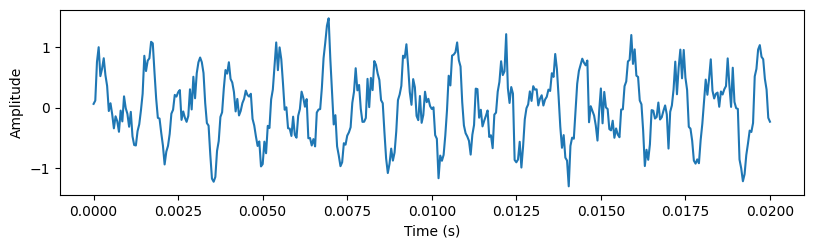

In [15]:
# Load the audio file
audio_file = "m313LinearAlgebra_Python/Assignment_3/dial_audio.wav"
fs, dial_audio = wavfile.read(audio_file)
print(f"Loaded audio with sampling rate {fs} and shape {dial_audio.shape}")

plot_duration = 0.02
idx = t <= plot_duration
plt.figure(figsize=(9.6, 2.4))
plt.plot(t[idx], dial_audio[:t.size][idx])
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

display(Audio(dial_audio, rate=fs))

Next, we chop the audio into segment of $1$ second.

In [16]:
# Split the audio into segments of 1 second
segments = dial_audio.reshape(-1, t.size)

Write a function `fourier_coefficients` to obtain the Fourier coefficients for a $1$-second segment:

In [17]:
# Compute the Fourier coefficients for a 1-second segment
def fourier_coefficients(x, B):
### Solution ###
  return np.array([inner_product(x, b) for b in B])

### Solution ###

Next, use the following codes to visualize your results on the given dial audio.
You will see clearly how each $1$-second segment is decomposed in terms of a pair of pure tones from the touch pad.

[[-0.002224  0.502834 -0.000271 -0.003294 -0.001168  0.499121 -0.002563]
 [-0.001384  0.000328  0.501309  0.000229  0.497287  0.000622  0.001314]
 [ 0.500708 -0.000834 -0.002007 -0.001289  0.004941 -0.00059   0.502385]
 [-0.00326   0.501718 -0.000251 -0.000026  0.001199  0.497571  0.002277]
 [ 0.499032 -0.000077  0.00238  -0.001951  0.000829  0.501033  0.001066]
 [ 0.000414  0.000648  0.496368  0.002822 -0.000308 -0.002161  0.497333]
 [-0.001278  0.497613 -0.001296  0.0013    0.500552  0.000023  0.001271]
 [ 0.499623 -0.000081 -0.00205   0.000934  0.001348  0.501553 -0.00123 ]
 [-0.0009    0.501305 -0.001504  0.001429  0.499794 -0.002174  0.000026]
 [-0.000113 -0.00261   0.500492  0.002773  0.000156  0.000863  0.500715]]


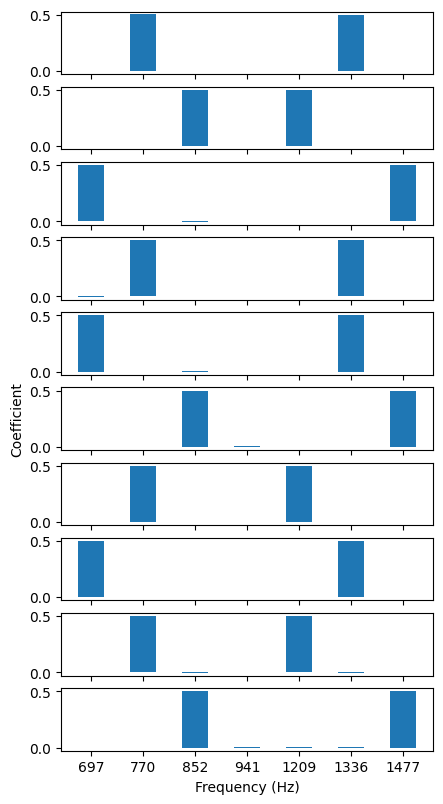

In [18]:
# Use these random numbers for testing the results
coefficients = np.random.rand(len(segments), n_bases)

# When you are done, uncomment this line for your solution
coefficients = np.array([fourier_coefficients(segment, B) for segment in segments])


with np.printoptions(precision=6, suppress=True):
    print(coefficients)

fig, axs = plt.subplots(len(segments), 1, figsize=(4.8, 9.6), sharex=True, sharey=True)
for i in range(len(segments)):
    axs[i].bar(np.arange(n_bases), coefficients[i], width=0.5)
    axs[i].set_xticks(np.arange(n_bases), all_freqs)
axs[-1].set_xlabel('Frequency (Hz)')
axs[len(segments) // 2].set_ylabel('Coefficient')
plt.show()

Complete the following codes to get the double indices (row, column) of the largest two coefficients for each $1$-second segment by

1. First split the coefficients into row and column coefficients;
2. Next find the index of the largest coefficient of row frequencies and column frequencies.

In [19]:
# Get the indices of the largest two coefficients for each segment
def get_freq_indices(fourier_coeffs):
### Solution ###
    # split the coefficients into row and column coefficients
    row_coeffs = fourier_coeffs[:len(freq_row)]
    col_coeffs = fourier_coeffs[len(freq_row):]

    # find the index of the largest coefficient of row frequencies and column frequencies
    row_freq_idx = np.argmax(row_coeffs)
    col_freq_idx = np.argmax(col_coeffs)

    return row_freq_idx, col_freq_idx

### Solution ###

Finally, run the following cell to decode the phone number from the given dial audio! __IT IS MY NUMBER PLEASE DO NOT CALL!__


In [20]:
freq_indices = np.array([get_freq_indices(coef) for coef in coefficients])
print(freq_indices)

# Look up the phone numbers in `touch_pad` with the frequency indices
phone_number = []
for row_freq_idx, col_freq_idx in freq_indices:
    phone_number.append(touch_pad[row_freq_idx, col_freq_idx])

# Convert the list to a string
phone_number = ''.join(phone_number)

print(phone_number)

[[1 1]
 [2 0]
 [0 2]
 [1 1]
 [0 1]
 [2 2]
 [1 0]
 [0 1]
 [1 0]
 [2 2]]
5735294249
